Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best parameters found:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}

=== Gradient Boosting Optimized ===
Accuracy: 0.5963759458383114
Log loss: 0.8939482838666606
              precision    recall  f1-score   support

    Away win       0.60      0.59      0.60      1546
        Draw       0.26      0.04      0.07      1143
    Home win       0.61      0.87      0.72      2333

    accuracy                           0.60      5022
   macro avg       0.49      0.50      0.46      5022
weighted avg       0.53      0.60      0.53      5022



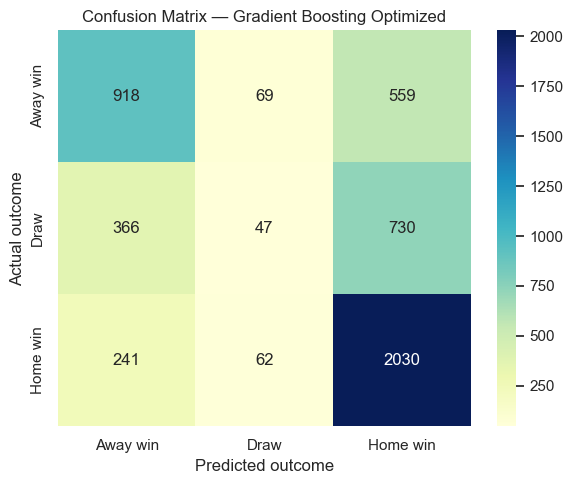

C:\Users\javir\AppData\Local\Temp\ipykernel_3296\2115035276.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=feat_imp, palette="magma")


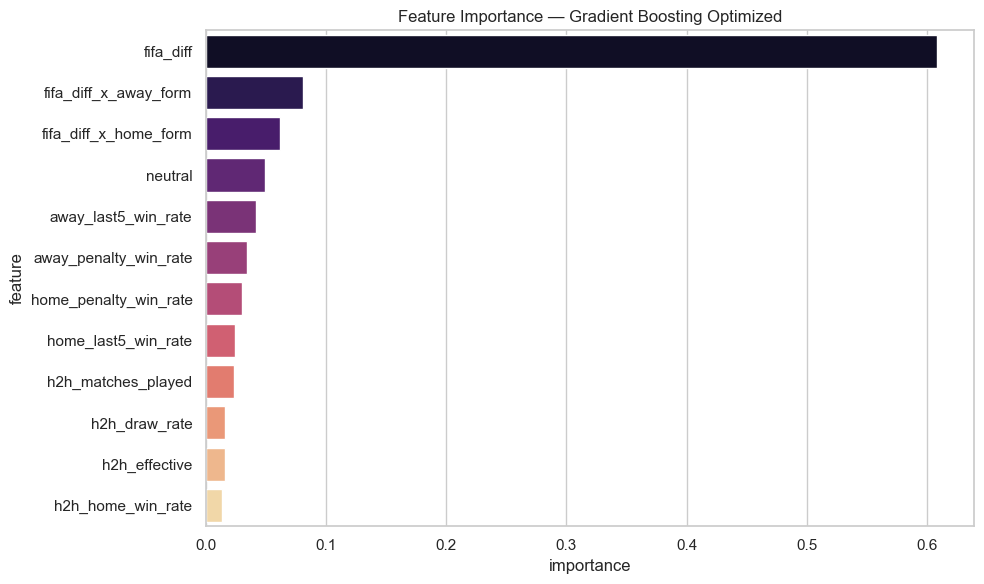

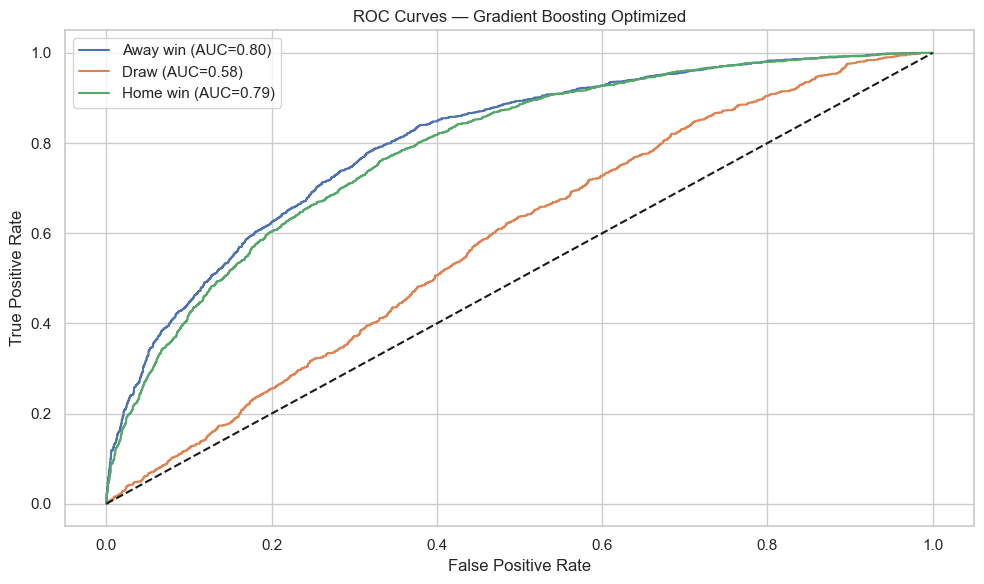

Gradient Boosting model saved as 'gradient_boosting_v1.pkl'


In [ ]:
# ============================================================
# 03_modeling.ipynb
# ============================================================
# Train predictive models for international football matches
# Using FIFA ranking, recent form, H2H stats, penalties
# With hyperparameter tuning for Gradient Boosting
# ============================================================

# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, roc_curve, roc_auc_score
)
import joblib

# =========================
# LOAD DATASET WITH FEATURES
# =========================
df = pd.read_csv(
    "../data/processed/matches_2000_onwards_features_fifa.csv"
)

# =========================
# TARGET VARIABLE
# =========================
df['target'] = np.select(
    [
        df['away_win'] == 1,
        df['draw'] == 1,
        df['home_win'] == 1
    ],
    [0, 1, 2]
)

# =========================
# FEATURE ENGINEERING: INTERACTIONS
# =========================
df['fifa_diff_x_home_form'] = df['fifa_diff'] * df['home_last5_win_rate']
df['fifa_diff_x_away_form'] = df['fifa_diff'] * df['away_last5_win_rate']
df['h2h_effective'] = df['h2h_home_win_rate'] * df['h2h_matches_played']

features = [
    'fifa_diff', 'home_last5_win_rate', 'away_last5_win_rate',
    'h2h_home_win_rate', 'h2h_draw_rate', 'h2h_matches_played',
    'home_penalty_win_rate', 'away_penalty_win_rate',
    'neutral',
    # interactions
    'fifa_diff_x_home_form', 'fifa_diff_x_away_form', 'h2h_effective'
]

# =========================
# TRAIN / TEST SPLIT
# =========================
split_year = 2018
train_df = df[df['year'] < split_year]
test_df  = df[df['year'] >= split_year]

X_train = train_df[features]
y_train = train_df['target']
X_test  = test_df[features]
y_test  = test_df['target']

# =========================
# HYPERPARAMETER TUNING FOR GRADIENT BOOSTING
# =========================
param_grid = {
    "n_estimators": [200, 500],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

tscv = TimeSeriesSplit(n_splits=5)

gb_model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_log_loss',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\nBest parameters found:")
print(grid_search.best_params_)

best_gb = grid_search.best_estimator_

# =========================
# PREDICTIONS & METRICS
# =========================
y_pred_gb = best_gb.predict(X_test)
y_proba_gb = best_gb.predict_proba(X_test)

print("\n=== Gradient Boosting Optimized ===")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Log loss:", log_loss(y_test, y_proba_gb))
print(classification_report(y_test, y_pred_gb, target_names=["Away win", "Draw", "Home win"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_gb)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="YlGnBu",
    xticklabels=["Away win", "Draw", "Home win"],
    yticklabels=["Away win", "Draw", "Home win"]
)
plt.title("Confusion Matrix — Gradient Boosting Optimized")
plt.xlabel("Predicted outcome")
plt.ylabel("Actual outcome")
plt.tight_layout()
plt.show()

# Feature importance
importances = best_gb.feature_importances_
feat_imp = pd.DataFrame({"feature": features, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_imp, palette="magma")
plt.title("Feature Importance — Gradient Boosting Optimized")
plt.tight_layout()
plt.show()

# ============================================================
# ROC CURVES (MULTI-CLASS)
# ============================================================
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(10,6))
for i, outcome in enumerate(["Away win", "Draw", "Home win"]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_gb[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_proba_gb[:, i])
    plt.plot(fpr, tpr, label=f"{outcome} (AUC={auc_score:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.title("ROC Curves — Gradient Boosting Optimized")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# SAVE BEST MODEL
# ============================================================
joblib.dump(best_gb, "../models/gradient_boosting_v1.pkl")
print("Gradient Boosting model saved as 'gradient_boosting_v1.pkl'")

